# Batch Docking: Candidate Compounds vs TBXT Pocket C

Dock all candidate compounds from the CWML virtual screen export against
the TBXT-C pocket, rank by docking score, then run full interaction
analysis and 3D visualization for the top 3.

In [1]:
import pandas as pd
from tbxt_hackathon.docking import dock_batch, dock_single

## 1. Load candidates

In [2]:
POCKET_PDB = "../data/structures/TGT_TBXT_C_pocket.pdb"

candidates = pd.read_csv(
    "../data/candidates-TBXT-cwml-C.csv"
)
assert candidates.shape[0] > 0, "No candidates loaded"

smiles_list = candidates["Molecule"].tolist()
ids = candidates["Id"].tolist()
print(f"Loaded {len(smiles_list)} candidates")

Loaded 10 candidates


## 2. Batch docking (fast scoring)

3 conformers per compound, exhaustiveness=3, 1 pose each for speed.

In [3]:
batch_scores = dock_batch(
    smiles_list,
    POCKET_PDB,
    n_conformers=3,
    exhaustiveness=3,
    n_poses=1,
)
assert batch_scores.shape[0] == len(smiles_list)

batch_scores.insert(1, "id", ids)
batch_scores = batch_scores.sort_values("score").reset_index(drop=True)
print(f"Successfully docked: {(batch_scores['status'] == 'ok').sum()} / {len(batch_scores)}")
batch_scores.head(10).style.background_gradient(subset=["score"], cmap="RdYlGn_r")

Successfully docked: 10 / 10


,smiles,id,score,ligand_efficiency,n_heavy_atoms,mw,score_std,status
0,CN1CCN(c2ccc(C(=O)Nc3cc(-c4nc5ccccc5[nH]4)[nH]n3)cc2)CC1,SM-GB558ZRC,-5.805000,0.193500,30,401.470000,0.156000,ok
1,N#Cc1ccccc1CN1CCC(Nc2ccc3c(cnn3C3CC3)c2F)CC1,SM-74ZN39VS,-5.747000,0.198200,29,389.480000,0.067000,ok
2,Cc1ccncc1NC(=O)N1CC(CC(=O)O)Cc2ccccc21,SM-6LDMD2J5,-5.418000,0.225800,24,325.370000,0.104000,ok
3,O=C(O)CC1C(=O)Nc2ccccc2N1C(=O)Nc1cnccc1-c1ccccc1,SM-CMDWBDUY,-5.351000,0.178400,30,402.410000,0.063000,ok
4,COc1cccc(CNC(=O)Nc2nc(-c3ccncc3)cs2)c1,SM-2TZ67HEX,-5.347000,0.222800,24,340.410000,0.036000,ok
5,COc1ccccc1CN1CCC(Nc2ccc3nc(C)c(=O)[nH]c3c2F)CC1,SM-W9DDSFF5,-5.226000,0.180200,29,396.470000,0.034000,ok
6,Cc1nccn1-c1ccncc1NC(=O)N1c2ccccc2C[C@@]1(C)C(=O)O,SM-J3USR2A1,-5.140000,0.183600,28,377.400000,0.028000,ok
7,CSc1ncc(C(=O)O)c(NC2CCN(Cc3ccccc3)CC2)n1,SM-TV7LYEHV,-5.096000,0.203800,25,358.470000,0.051000,ok
8,CCCCNC(=O)NS(=O)(=O)c1cnccc1Nc1cccc(C)c1,SM-X13DLSR7,-4.888000,0.195500,25,362.460000,0.102000,ok
9,CCCc1cc(=O)[nH]c(SCC(=O)Nc2ccc(OC(F)F)cc2)n1,SM-UM78GNFL,-4.807000,0.192300,25,369.390000,0.056000,ok


## 3. Score distribution

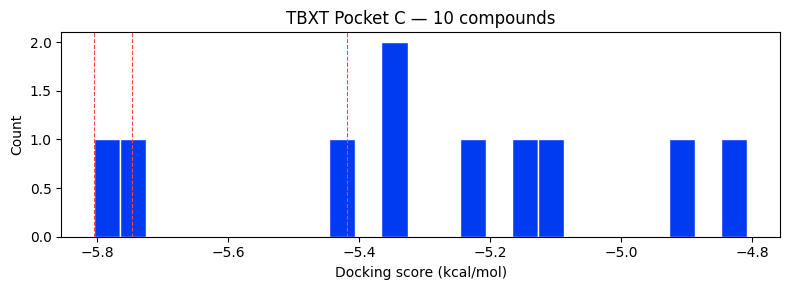

In [4]:
import matplotlib.pyplot as plt

ok = batch_scores[batch_scores["status"] == "ok"]

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ok["score"], bins=25, edgecolor="white", color="#013BF1")
ax.set_xlabel("Docking score (kcal/mol)")
ax.set_ylabel("Count")
ax.set_title(f"TBXT Pocket C — {len(ok)} compounds")

for i, row in ok.head(3).iterrows():
    ax.axvline(row["score"], color="#FF4444", ls="--", lw=0.8)

plt.tight_layout()
plt.show()

## 4. Full docking & 3D poses for top 3

Re-dock the top 3 with higher exhaustiveness and multiple poses for
detailed interaction analysis.

In [5]:
top3 = batch_scores[batch_scores["status"] == "ok"].head(3)

reports = []
for _, row in top3.iterrows():
    print(f"\nDocking {row['id']} ...")
    rpt = dock_single(
        row["smiles"],
        POCKET_PDB,
        n_conformers=3,
        exhaustiveness=32,
        n_poses=5,
    )
    reports.append((row["id"], rpt))
    print(rpt.summary())


Docking SM-GB558ZRC ...
Docking report: CN1CCN(c2ccc(C(=O)Nc3cc(-c4nc5ccccc5[nH]4)[nH]n3)cc2)CC1
  Best score:        -5.77 kcal/mol  (conformer 0, pose 0)
  Inter-molecular:   -7.11 kcal/mol
  Intra-molecular:   -0.33 kcal/mol
  Ligand efficiency: 0.192 kcal/mol/HA
  Heavy atoms:       30
  MW:                401.5
  Conformers run:    3
  Total poses:       15
  Score range:       -5.77 to -5.13 kcal/mol

  Best-pose interactions (7):
    pi_stacking    PHE33    ring  4.84 A, angle=87  (edge_to_face)
    pi_stacking    PHE33    ring  5.17 A, angle=87  (edge_to_face)
    hydrophobic    LEU12    CD2   3.69 A
    hydrophobic    PHE33    CE1   3.51 A
    hydrophobic    VAL35    CG2   3.59 A
    hydrophobic    LYS37    CE    3.97 A
    hydrophobic    TYR171   CE1   3.74 A

Docking SM-74ZN39VS ...
Docking report: N#Cc1ccccc1CN1CCC(Nc2ccc3c(cnn3C3CC3)c2F)CC1
  Best score:        -5.78 kcal/mol  (conformer 0, pose 0)
  Inter-molecular:   -7.47 kcal/mol
  Intra-molecular:   -0.52 kcal/mol
  

### Rank 1

In [6]:
mol_id, rpt = reports[0]
print(f"{mol_id}: {rpt.score:.2f} kcal/mol  LE={rpt.ligand_efficiency:.3f}")
rpt.show_3d()

SM-GB558ZRC: -5.77 kcal/mol  LE=0.192


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Rank 2

In [7]:
mol_id, rpt = reports[1]
print(f"{mol_id}: {rpt.score:.2f} kcal/mol  LE={rpt.ligand_efficiency:.3f}")
rpt.show_3d()

SM-74ZN39VS: -5.78 kcal/mol  LE=0.199


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Rank 3

In [8]:
mol_id, rpt = reports[2]
print(f"{mol_id}: {rpt.score:.2f} kcal/mol  LE={rpt.ligand_efficiency:.3f}")
rpt.show_3d()

SM-6LDMD2J5: -5.41 kcal/mol  LE=0.225


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 5. Interaction comparison

In [9]:
rows = []
for mol_id, rpt in reports:
    bp = rpt.best_pose
    rows.append({
        "id": mol_id,
        "smiles": rpt.smiles,
        "score": rpt.score,
        "LE": rpt.ligand_efficiency,
        "HA": rpt.n_heavy_atoms,
        "inter": bp.inter_energy,
        "intra": bp.intra_energy,
        "hbonds": sum(1 for x in bp.interactions if x.type == "hbond"),
        "hydrophobic": sum(1 for x in bp.interactions if x.type == "hydrophobic"),
        "pi_stack": sum(1 for x in bp.interactions if x.type == "pi_stacking"),
        "salt_bridge": sum(1 for x in bp.interactions if x.type == "salt_bridge"),
        "total_interactions": len(bp.interactions),
        "key_residues": ", ".join(sorted({x.protein_residue for x in bp.interactions})),
    })

comparison = pd.DataFrame(rows)
comparison.style.background_gradient(subset=["score"], cmap="RdYlGn_r")

,id,smiles,score,LE,HA,inter,intra,hbonds,hydrophobic,pi_stack,salt_bridge,total_interactions,key_residues
0,SM-GB558ZRC,CN1CCN(c2ccc(C(=O)Nc3cc(-c4nc5ccccc5[nH]4)[nH]n3)cc2)CC1,-5.766000,0.192200,30,-7.114000,-0.325000,0,5,2,0,7,"LEU12, LYS37, PHE33, TYR171, VAL35"
1,SM-74ZN39VS,N#Cc1ccccc1CN1CCC(Nc2ccc3c(cnn3C3CC3)c2F)CC1,-5.783000,0.199414,29,-7.474000,-0.515000,0,5,1,0,6,"GLU11, GLU9, LEU12, PHE33, VAL35"
2,SM-6LDMD2J5,Cc1ccncc1NC(=O)N1CC(CC(=O)O)Cc2ccccc21,-5.408000,0.225333,24,-6.830000,-0.795000,0,5,0,0,5,"ARG15, GLU11, GLU9, LEU12, TYR171"


## 6. Save results

In [10]:
batch_scores.to_csv("../data/docking_scores_pocket_C.csv", index=False)
comparison.to_csv("../data/docking_top3_pocket_C.csv", index=False)
print("Saved to data/docking_scores_pocket_C.csv and data/docking_top3_pocket_C.csv")

Saved to data/docking_scores_pocket_C.csv and data/docking_top3_pocket_C.csv
